In [2]:
import gpflow as gpf
import tensorflow as tf
import numpy as np
import sys
sys.path.append("../..")
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from gpflow.covariances.dispatch import Kuf, Kuu
from gpflow.utilities import to_default_float, assert_params_false, add_likelihood_noise_cov
from gpflow.config import default_jitter, default_float
from gpflow.utilities import to_default_float
from gpflow.models.util import InducingPointsLike, data_input_to_tensor, inducingpoint_wrapper
from gpflow.inducing_variables import InducingPoints
from typing import NamedTuple


from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

2026-06-09 17:16:42.512992: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 17:16:42.515331: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-09 17:16:42.552055: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-09 17:16:42.553069: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-09 17:16:43.328735: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

[   0   20   40   60   80  100  120  140  160  180  200  220  240  260
  280  300  320  340  360  380  400  420  440  460  480  500  520  540
  560  580  600  620  640  660  680  700  720  740  760  780  800  820
  840  860  880  900  920  940  960  980 1000 1020 1040 1060 1080 1100
 1120 1140 1160 1180 1200 1220 1240 1260 1280 1300 1320 1340 1360 1380
 1400 1420 1440 1460 1480 1500 1520 1540 1560 1580 1600 1620 1640 1660
 1680 1700 1720 1740 1760 1780 1800 1820 1840 1860 1880 1900 1920 1940
 1960 1980 2000 2020 2040 2060 2080 2100 2120 2140 2160 2180 2200 2220
 2240 2260 2280 2300 2320 2340 2360 2380 2400 2420 2440 2460 2480 2500
 2520 2540 2560 2580 2600 2620 2640 2660 2680 2700 2720 2740 2760 2780
 2800 2820 2840 2860 2880 2900 2920 2940 2960 2980 3000 3020 3040 3060
 3080 3100 3120 3140 3160 3180 3200 3220 3240 3260 3280 3300 3320 3340
 3360 3380 3400 3420 3440 3460 3480 3500 3520 3540 3560 3580 3600 3620
 3640 3660 3680 3700 3720 3740 3760 3780 3800 3820 3840 3860 3880 3900
 3920 

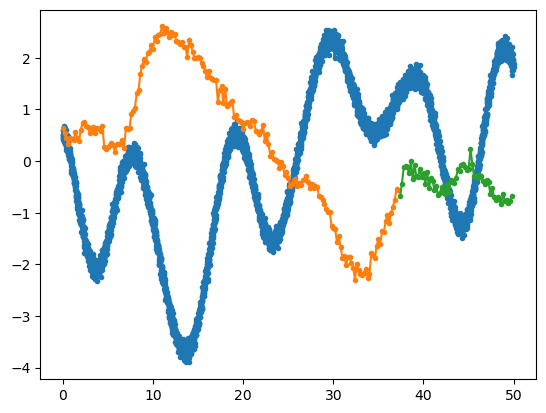

In [3]:
k = gpf.kernels.RBF(lengthscales=3, variance=1) #+ gpf.kernels.Linear(0.001)
NDP = 5000
Xall = np.linspace(0, 50, NDP)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, NDP, 1)
ind_2 = np.array([i for i in ind_1 if i % 20 == 0])
ind_1 = ind_1
ind_2 = ind_2 
print(ind_2)
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1] + np.random.multivariate_normal(np.zeros_like(Xall[ind_1]), gpf.kernels.Cosine(variance=1, lengthscales=10)(Xall[ind_1].reshape(-1, 1)))
X2 = Xall[ind_train]
y2 = Yall[ind_train]

X2 = X2 - X2[0]
scalar = -1
y2 = scalar * y2
y2 = y2
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest = scalar * ytest.reshape(-1, 1) + np.random.normal(0, 0.1, len(Xtest)).reshape(-1, 1)

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.1, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.1, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
y2 = y2 
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ Spar

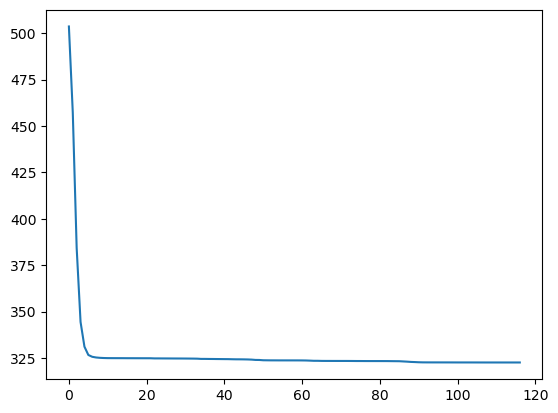

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.01678                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0014407032004201351   │
├────────────────────────────────────────────────┼───────────┼──────────────────┼───────

In [4]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 20
ivs = np.linspace(0, max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-5, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

NameError: name 'ymean' is not defined

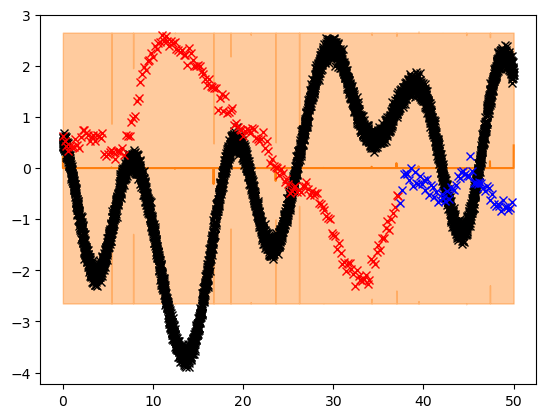

In [5]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
#plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)

ivs = np.linspace(0, max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((int(len(ivs)/2),1 )), np.zeros((int(len(ivs)/2), 1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-06-09 17:07:56.390870: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-06-09 17:07:56.425105: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -3614.556087769898
        x: [-2.241e-01  1.565e+00 ... -4.488e+00 -1.059e+00]
      nit: 13784
      jac: [ 1.239e-01  7.376e-02 ...  5.827e-02 -4.411e-02]
     nfev: 14823
     njev: 14823
 hess_inv: <278x278 LbfgsInvHessProduct with dtype=float64>

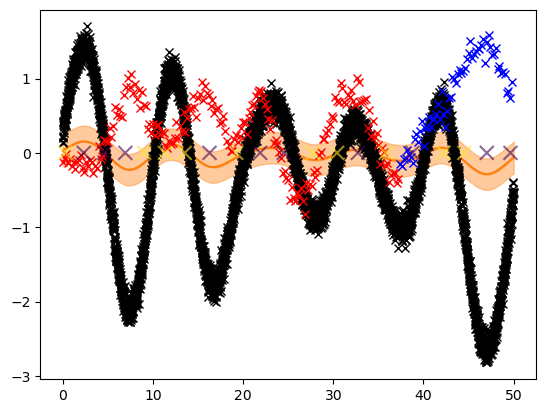

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤═══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                 │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪═══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 0.17974832243599592                                   │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼───────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()    

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

svgp_mse = mean_squared_error(ytest, fmean_tst)
svgp_mse

gpf.utilities.print_summary(m)
print(svgp_mse)